# Entrega - Agente Santi (Minimax + Alpha-Beta)

Este notebook documenta el estudio del agente con enfoque en la variable numerica **DEPTH** (lookahead).

Objetivos:
- medir rendimiento vs jugador aleatorio por color,
- medir autodesempeño (self-play),
- cuantificar costo computacional (tiempo por jugada),
- soportar conclusiones con graficas.

In [1]:
import sys
import time
import random
from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt

# Ubica automaticamente la carpeta tournament para que los imports funcionen
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'connect4').exists():
    ROOT = ROOT.parent

if not (ROOT / 'connect4').exists():
    raise RuntimeError('No se encontro la carpeta connect4. Ejecuta este notebook dentro del proyecto.')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from connect4.connect_state import ConnectState

SantiPolicy = importlib.import_module('groups.Group Santi.policy').SantiPolicy
RandomPolicy = importlib.import_module('groups.Group B.policy').Hello

print('Project root:', ROOT)
print('SantiPolicy:', SantiPolicy)
print('RandomPolicy:', RandomPolicy)

Project root: D:\USabana\2026-1\IA\Proyecto-Final-Fundamentos-de-IA\tournament
SantiPolicy: <class 'groups.Group Santi.policy.SantiPolicy'>
RandomPolicy: <class 'groups.Group B.policy.Hello'>


In [2]:
def _safe_mount(policy):
    try:
        policy.mount(None)
    except TypeError:
        policy.mount()


def play_single_game(red_cls, yellow_cls, measure_santi=False):
    red = red_cls()
    yellow = yellow_cls()
    _safe_mount(red)
    _safe_mount(yellow)

    state = ConnectState()
    santi_time = 0.0
    santi_moves = 0

    while not state.is_final():
        current_policy = red if state.player == -1 else yellow
        is_santi_turn = measure_santi and isinstance(current_policy, SantiPolicy)

        if is_santi_turn:
            t0 = time.perf_counter()
            action = int(current_policy.act(state.board))
            santi_time += time.perf_counter() - t0
            santi_moves += 1
        else:
            action = int(current_policy.act(state.board))

        state = state.transition(action)

    return state.get_winner(), santi_moves, santi_time


def eval_vs_random(depth, games_per_color=60):
    SantiPolicy.DEPTH = int(depth)

    red_wins = red_draws = red_losses = 0
    yellow_wins = yellow_draws = yellow_losses = 0
    total_santi_time = 0.0
    total_santi_moves = 0

    # Santi rojo (-1)
    for _ in range(games_per_color):
        winner, m, t = play_single_game(SantiPolicy, RandomPolicy, measure_santi=True)
        total_santi_moves += m
        total_santi_time += t
        if winner == -1:
            red_wins += 1
        elif winner == 0:
            red_draws += 1
        else:
            red_losses += 1

    # Santi amarillo (1)
    for _ in range(games_per_color):
        winner, m, t = play_single_game(RandomPolicy, SantiPolicy, measure_santi=True)
        total_santi_moves += m
        total_santi_time += t
        if winner == 1:
            yellow_wins += 1
        elif winner == 0:
            yellow_draws += 1
        else:
            yellow_losses += 1

    red_total = red_wins + red_draws + red_losses
    yellow_total = yellow_wins + yellow_draws + yellow_losses

    return {
        'depth': int(depth),
        'games_per_color': int(games_per_color),
        'red_wins': red_wins,
        'red_draws': red_draws,
        'red_losses': red_losses,
        'yellow_wins': yellow_wins,
        'yellow_draws': yellow_draws,
        'yellow_losses': yellow_losses,
        'red_win_rate': red_wins / red_total if red_total else 0.0,
        'yellow_win_rate': yellow_wins / yellow_total if yellow_total else 0.0,
        'global_win_rate': (red_wins + yellow_wins) / (red_total + yellow_total),
        'avg_santi_ms_per_move': 1000.0 * total_santi_time / max(total_santi_moves, 1),
    }


def eval_self_play(depth, games=40):
    SantiPolicy.DEPTH = int(depth)

    red_wins = yellow_wins = draws = 0
    for _ in range(games):
        winner, _, _ = play_single_game(SantiPolicy, SantiPolicy, measure_santi=False)
        if winner == -1:
            red_wins += 1
        elif winner == 1:
            yellow_wins += 1
        else:
            draws += 1

    return {
        'depth': int(depth),
        'self_red_wins': red_wins,
        'self_yellow_wins': yellow_wins,
        'self_draws': draws,
        'self_draw_rate': draws / max(games, 1),
    }

## Configuracion del estudio

Se puede cambiar `DEPTHS`, `GAMES_PER_COLOR` y `SELF_GAMES` segun el tiempo disponible.

In [3]:
DEPTHS = [2, 3, 4, 5]
GAMES_PER_COLOR = 40
SELF_GAMES = 30

print('DEPTHS:', DEPTHS)
print('Games vs random per color:', GAMES_PER_COLOR)
print('Self-play games:', SELF_GAMES)

DEPTHS: [2, 3, 4, 5]
Games vs random per color: 40
Self-play games: 30


In [4]:
# Estimador rapido de tiempo (micro-benchmark).
# Sirve para decidir si incluir depth 5 o 6 antes de lanzar corridas largas.

def quick_timing(depth, probe_games_per_color=4):
    t0 = time.perf_counter()
    _ = eval_vs_random(depth, games_per_color=probe_games_per_color)
    dt = time.perf_counter() - t0
    games = 2 * probe_games_per_color
    return dt / games

timing_probe = {}
for d in DEPTHS:
    avg_sec_per_game = quick_timing(d, probe_games_per_color=4)
    timing_probe[d] = avg_sec_per_game

print('Promedio aproximado por partida (segundos):')
for d in DEPTHS:
    print(f'  depth={d}: {timing_probe[d]:.3f}s/game')

estimated_total_sec = sum(timing_probe[d] * (2 * GAMES_PER_COLOR + SELF_GAMES) for d in DEPTHS)
print(f'Estimacion total del estudio actual: {estimated_total_sec/60:.1f} min')

Promedio aproximado por partida (segundos):
  depth=2: 0.102s/game
  depth=3: 0.309s/game
  depth=4: 1.862s/game
  depth=5: 3.232s/game
Estimacion total del estudio actual: 10.1 min


In [5]:
vs_random_results = []
self_play_results = []

for d in DEPTHS:
    print(f'Corriendo depth={d} ...')
    vs_random_results.append(eval_vs_random(d, games_per_color=GAMES_PER_COLOR))
    self_play_results.append(eval_self_play(d, games=SELF_GAMES))

print('Listo.')

for row in vs_random_results:
    print(row)

for row in self_play_results:
    print(row)

Corriendo depth=2 ...
Corriendo depth=3 ...
Corriendo depth=4 ...
Corriendo depth=5 ...
Listo.
{'depth': 2, 'games_per_color': 40, 'red_wins': 40, 'red_draws': 0, 'red_losses': 0, 'yellow_wins': 40, 'yellow_draws': 0, 'yellow_losses': 0, 'red_win_rate': 1.0, 'yellow_win_rate': 1.0, 'global_win_rate': 1.0, 'avg_santi_ms_per_move': 18.721067843845457}
{'depth': 3, 'games_per_color': 40, 'red_wins': 40, 'red_draws': 0, 'red_losses': 0, 'yellow_wins': 40, 'yellow_draws': 0, 'yellow_losses': 0, 'red_win_rate': 1.0, 'yellow_win_rate': 1.0, 'global_win_rate': 1.0, 'avg_santi_ms_per_move': 45.96228279364817}
{'depth': 4, 'games_per_color': 40, 'red_wins': 40, 'red_draws': 0, 'red_losses': 0, 'yellow_wins': 40, 'yellow_draws': 0, 'yellow_losses': 0, 'red_win_rate': 1.0, 'yellow_win_rate': 1.0, 'global_win_rate': 1.0, 'avg_santi_ms_per_move': 207.60993137255335}
{'depth': 5, 'games_per_color': 40, 'red_wins': 40, 'red_draws': 0, 'red_losses': 0, 'yellow_wins': 40, 'yellow_draws': 0, 'yellow_loss

In [6]:
# Guarda resultados crudos para incluirlos en el PDF si hace falta.

import json
out_dir = ROOT / 'groups' / 'Group Santi' / 'results'
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / 'vs_random_depth_sweep.json', 'w', encoding='utf-8') as f:
    json.dump(vs_random_results, f, indent=2)

with open(out_dir / 'self_play_depth_sweep.json', 'w', encoding='utf-8') as f:
    json.dump(self_play_results, f, indent=2)

print('Resultados guardados en:', out_dir)

Resultados guardados en: D:\USabana\2026-1\IA\Proyecto-Final-Fundamentos-de-IA\tournament\groups\Group Santi\results


Este agente usa minimax con poda alpha-beta. La variable estudiada fue `DEPTH` porque controla al mismo tiempo la profundidad de búsqueda y el costo de cómputo. En los experimentos se comparó el agente contra un jugador aleatorio por color y contra sí mismo, todo esto con el objetivo de ver hasta qué punto subir la profundidad mejora el juego sin volverlo demasiado caro.

Una forma natural de redactar la conclusión es esta: "A partir de depth X, las mejoras en winrate fueron pequeñas frente al aumento del costo computacional, por lo que se escogió depth Y como mejor punto de equilibrio".

También hay que tener en cuenta el cosntraint del torneo en el cual el límite de tiempo por jugada es de 10s, por lo cual un `DEPTH` demasiado alto es demorado y no serviría.

{'depth': 2, 'red_wins': 40, 'red_losses': 0, 'yellow_wins': 40, 'yellow_losses': 0, 'global_win_rate': 1.0, 'avg_ms_per_move': 18.7, 'self_draw_rate': 0.0}
{'depth': 3, 'red_wins': 40, 'red_losses': 0, 'yellow_wins': 40, 'yellow_losses': 0, 'global_win_rate': 1.0, 'avg_ms_per_move': 46.0, 'self_draw_rate': 0.0}
{'depth': 4, 'red_wins': 40, 'red_losses': 0, 'yellow_wins': 40, 'yellow_losses': 0, 'global_win_rate': 1.0, 'avg_ms_per_move': 207.6, 'self_draw_rate': 0.133}
{'depth': 5, 'red_wins': 40, 'red_losses': 0, 'yellow_wins': 40, 'yellow_losses': 0, 'global_win_rate': 1.0, 'avg_ms_per_move': 522.5, 'self_draw_rate': 0.0}


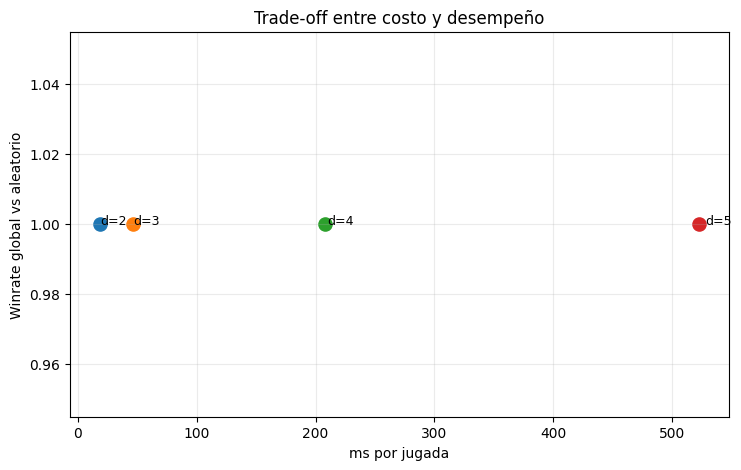

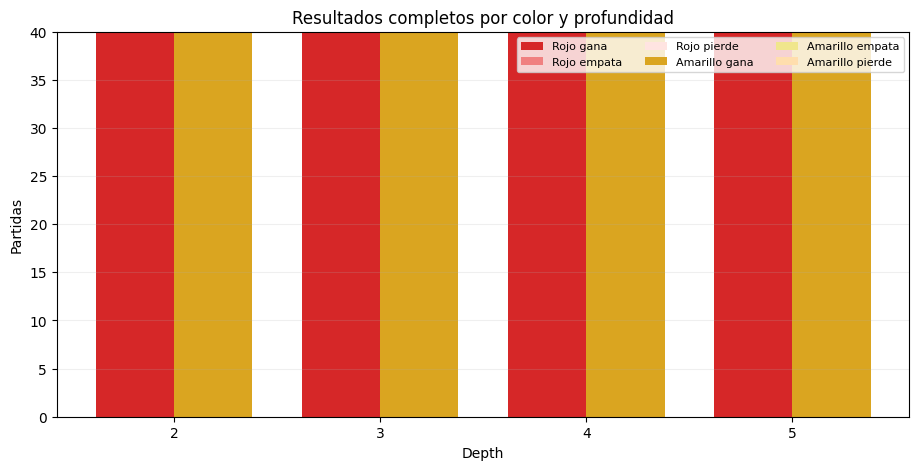

In [11]:
summary_rows = []
for r, s in zip(vs_random_results, self_play_results):
    summary_rows.append({
        'depth': r['depth'],
        'red_wins': r['red_wins'],
        'red_losses': r['red_losses'],
        'yellow_wins': r['yellow_wins'],
        'yellow_losses': r['yellow_losses'],
        'global_win_rate': round(r['global_win_rate'], 3),
        'avg_ms_per_move': round(r['avg_santi_ms_per_move'], 1),
        'self_draw_rate': round(s['self_draw_rate'], 3),
    })

for row in summary_rows:
    print(row)

plt.figure(figsize=(8.5, 5))
for row in summary_rows:
    plt.scatter(row['avg_ms_per_move'], row['global_win_rate'], s=90)
    plt.text(row['avg_ms_per_move'] * 1.01, row['global_win_rate'], f"d={row['depth']}", fontsize=9)
plt.xlabel('ms por jugada')
plt.ylabel('Winrate global vs aleatorio')
plt.title('Trade-off entre costo y desempeño')
plt.grid(alpha=0.25)
plt.show()

labels = [str(r['depth']) for r in vs_random_results]
red_stack = [r['red_wins'] for r in vs_random_results]
red_draw_stack = [r['red_draws'] for r in vs_random_results]
red_loss_stack = [r['red_losses'] for r in vs_random_results]
yellow_stack = [r['yellow_wins'] for r in vs_random_results]
yellow_draw_stack = [r['yellow_draws'] for r in vs_random_results]
yellow_loss_stack = [r['yellow_losses'] for r in vs_random_results]

x = np.arange(len(labels))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, red_stack, width, label='Rojo gana', color='tab:red')
plt.bar(x - width/2, red_draw_stack, width, bottom=red_stack, label='Rojo empata', color='lightcoral')
plt.bar(x - width/2, red_loss_stack, width, bottom=np.array(red_stack) + np.array(red_draw_stack), label='Rojo pierde', color='mistyrose')
plt.bar(x + width/2, yellow_stack, width, label='Amarillo gana', color='goldenrod')
plt.bar(x + width/2, yellow_draw_stack, width, bottom=yellow_stack, label='Amarillo empata', color='khaki')
plt.bar(x + width/2, yellow_loss_stack, width, bottom=np.array(yellow_stack) + np.array(yellow_draw_stack), label='Amarillo pierde', color='navajowhite')
plt.xticks(x, labels)
plt.xlabel('Depth')
plt.ylabel('Partidas')
plt.title('Resultados completos por color y profundidad')
plt.grid(axis='y', alpha=0.2)
plt.legend(ncol=3, fontsize=8)
plt.show()

{'depth_red': 2, 'depth_yellow': 2, 'red_wins': 22, 'yellow_wins': 2, 'draws': 0, 'red_win_rate': 0.9166666666666666, 'yellow_win_rate': 0.08333333333333333, 'draw_rate': 0.0}
{'depth_red': 2, 'depth_yellow': 3, 'red_wins': 3, 'yellow_wins': 19, 'draws': 2, 'red_win_rate': 0.125, 'yellow_win_rate': 0.7916666666666666, 'draw_rate': 0.08333333333333333}
{'depth_red': 2, 'depth_yellow': 4, 'red_wins': 10, 'yellow_wins': 14, 'draws': 0, 'red_win_rate': 0.4166666666666667, 'yellow_win_rate': 0.5833333333333334, 'draw_rate': 0.0}
{'depth_red': 2, 'depth_yellow': 5, 'red_wins': 1, 'yellow_wins': 23, 'draws': 0, 'red_win_rate': 0.041666666666666664, 'yellow_win_rate': 0.9583333333333334, 'draw_rate': 0.0}
{'depth_red': 3, 'depth_yellow': 2, 'red_wins': 20, 'yellow_wins': 4, 'draws': 0, 'red_win_rate': 0.8333333333333334, 'yellow_win_rate': 0.16666666666666666, 'draw_rate': 0.0}
{'depth_red': 3, 'depth_yellow': 3, 'red_wins': 14, 'yellow_wins': 9, 'draws': 1, 'red_win_rate': 0.5833333333333334,

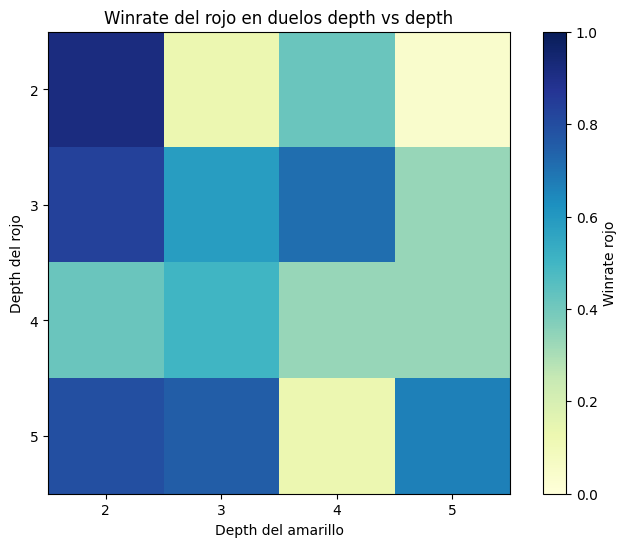

Mejor cruce por winrate del rojo: {'depth_red': 2, 'depth_yellow': 2, 'red_wins': 22, 'yellow_wins': 2, 'draws': 0, 'red_win_rate': 0.9166666666666666, 'yellow_win_rate': 0.08333333333333333, 'draw_rate': 0.0}


In [ ]:
def make_depth_policy(depth):
    return type(f'SantiDepth{depth}', (SantiPolicy,), {'DEPTH': int(depth)})


def play_policy_match(red_policy_cls, yellow_policy_cls):
    red = red_policy_cls()
    yellow = yellow_policy_cls()
    _safe_mount(red)
    _safe_mount(yellow)

    state = ConnectState()
    while not state.is_final():
        current_policy = red if state.player == -1 else yellow
        action = int(current_policy.act(state.board))
        state = state.transition(action)

    return state.get_winner()


def eval_depth_vs_depth(depth_red, depth_yellow, games=24):
    red_policy_cls = make_depth_policy(depth_red)
    yellow_policy_cls = make_depth_policy(depth_yellow)

    red_wins = yellow_wins = draws = 0
    for _ in range(games):
        winner = play_policy_match(red_policy_cls, yellow_policy_cls)
        if winner == -1:
            red_wins += 1
        elif winner == 1:
            yellow_wins += 1
        else:
            draws += 1

    return {
        'depth_red': int(depth_red),
        'depth_yellow': int(depth_yellow),
        'red_wins': red_wins,
        'yellow_wins': yellow_wins,
        'draws': draws,
        'red_win_rate': red_wins / max(games, 1),
        'yellow_win_rate': yellow_wins / max(games, 1),
        'draw_rate': draws / max(games, 1),
    }


depth_grid = DEPTHS
match_results = []
for d_red in depth_grid:
    for d_yellow in depth_grid:
        match_results.append(eval_depth_vs_depth(d_red, d_yellow, games=24))

for row in match_results:
    print(row)

# Matriz de winrate del rojo cuando juega con depth de fila contra depth de columna
win_matrix = np.zeros((len(depth_grid), len(depth_grid)))
for row in match_results:
    i = depth_grid.index(row['depth_red'])
    j = depth_grid.index(row['depth_yellow'])
    win_matrix[i, j] = row['red_win_rate']

plt.figure(figsize=(8.5, 6))
im = plt.imshow(win_matrix, cmap='YlGnBu', vmin=0, vmax=1, origin='lower')
plt.xticks(range(len(depth_grid)), depth_grid)
plt.yticks(range(len(depth_grid)), depth_grid)
plt.xlabel('Depth del amarillo')
plt.ylabel('Depth del rojo')
plt.title('Winrate del rojo en duelos depth vs depth')
plt.colorbar(im, label='Winrate rojo')

for i in range(len(depth_grid)):
    for j in range(len(depth_grid)):
        plt.text(j, i, f'{win_matrix[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()

# Un resumen simple para redactar en el informe
best_rows = sorted(match_results, key=lambda r: (r['red_win_rate'], -r['draw_rate']), reverse=True)
print('Mejor cruce por winrate del rojo:', best_rows[0])

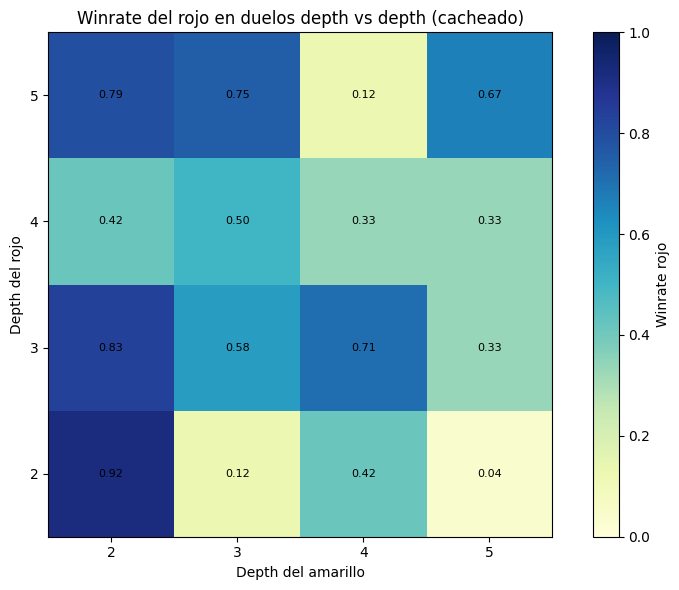

In [10]:
# Cambia el orden del heatmap pero se cargan valores de una primera run, demoró 30min
cached_match_results = [
    {'depth_red': 2, 'depth_yellow': 2, 'red_wins': 22, 'yellow_wins': 2, 'draws': 0, 'red_win_rate': 0.9166666666666666, 'yellow_win_rate': 0.08333333333333333, 'draw_rate': 0.0},
    {'depth_red': 2, 'depth_yellow': 3, 'red_wins': 3, 'yellow_wins': 19, 'draws': 2, 'red_win_rate': 0.125, 'yellow_win_rate': 0.7916666666666666, 'draw_rate': 0.08333333333333333},
    {'depth_red': 2, 'depth_yellow': 4, 'red_wins': 10, 'yellow_wins': 14, 'draws': 0, 'red_win_rate': 0.4166666666666667, 'yellow_win_rate': 0.5833333333333334, 'draw_rate': 0.0},
    {'depth_red': 2, 'depth_yellow': 5, 'red_wins': 1, 'yellow_wins': 23, 'draws': 0, 'red_win_rate': 0.041666666666666664, 'yellow_win_rate': 0.9583333333333334, 'draw_rate': 0.0},
    {'depth_red': 3, 'depth_yellow': 2, 'red_wins': 20, 'yellow_wins': 4, 'draws': 0, 'red_win_rate': 0.8333333333333334, 'yellow_win_rate': 0.16666666666666666, 'draw_rate': 0.0},
    {'depth_red': 3, 'depth_yellow': 3, 'red_wins': 14, 'yellow_wins': 9, 'draws': 1, 'red_win_rate': 0.5833333333333334, 'yellow_win_rate': 0.375, 'draw_rate': 0.041666666666666664},
    {'depth_red': 3, 'depth_yellow': 4, 'red_wins': 17, 'yellow_wins': 7, 'draws': 0, 'red_win_rate': 0.7083333333333334, 'yellow_win_rate': 0.2916666666666667, 'draw_rate': 0.0},
    {'depth_red': 3, 'depth_yellow': 5, 'red_wins': 8, 'yellow_wins': 16, 'draws': 0, 'red_win_rate': 0.3333333333333333, 'yellow_win_rate': 0.6666666666666666, 'draw_rate': 0.0},
    {'depth_red': 4, 'depth_yellow': 2, 'red_wins': 10, 'yellow_wins': 14, 'draws': 0, 'red_win_rate': 0.4166666666666667, 'yellow_win_rate': 0.5833333333333334, 'draw_rate': 0.0},
    {'depth_red': 4, 'depth_yellow': 3, 'red_wins': 12, 'yellow_wins': 12, 'draws': 0, 'red_win_rate': 0.5, 'yellow_win_rate': 0.5, 'draw_rate': 0.0},
    {'depth_red': 4, 'depth_yellow': 4, 'red_wins': 8, 'yellow_wins': 16, 'draws': 0, 'red_win_rate': 0.3333333333333333, 'yellow_win_rate': 0.6666666666666666, 'draw_rate': 0.0},
    {'depth_red': 4, 'depth_yellow': 5, 'red_wins': 8, 'yellow_wins': 15, 'draws': 1, 'red_win_rate': 0.3333333333333333, 'yellow_win_rate': 0.625, 'draw_rate': 0.041666666666666664},
    {'depth_red': 5, 'depth_yellow': 2, 'red_wins': 19, 'yellow_wins': 5, 'draws': 0, 'red_win_rate': 0.7916666666666666, 'yellow_win_rate': 0.20833333333333334, 'draw_rate': 0.0},
    {'depth_red': 5, 'depth_yellow': 3, 'red_wins': 18, 'yellow_wins': 6, 'draws': 0, 'red_win_rate': 0.75, 'yellow_win_rate': 0.25, 'draw_rate': 0.0},
    {'depth_red': 5, 'depth_yellow': 4, 'red_wins': 3, 'yellow_wins': 21, 'draws': 0, 'red_win_rate': 0.125, 'yellow_win_rate': 0.875, 'draw_rate': 0.0},
    {'depth_red': 5, 'depth_yellow': 5, 'red_wins': 16, 'yellow_wins': 7, 'draws': 1, 'red_win_rate': 0.6666666666666666, 'yellow_win_rate': 0.2916666666666667, 'draw_rate': 0.041666666666666664},
 ]

cached_depths = [2, 3, 4, 5]
cached_win_matrix = np.zeros((4, 4))
for row in cached_match_results:
    i = cached_depths.index(row['depth_red'])
    j = cached_depths.index(row['depth_yellow'])
    cached_win_matrix[i, j] = row['red_win_rate']

plt.figure(figsize=(8.5, 6))
im = plt.imshow(cached_win_matrix, cmap='YlGnBu', vmin=0, vmax=1, origin='lower')
plt.xticks(range(4), cached_depths)
plt.yticks(range(4), cached_depths)
plt.xlabel('Depth del amarillo')
plt.ylabel('Depth del rojo')
plt.title('Winrate del rojo en duelos depth vs depth (cacheado)')
plt.colorbar(im, label='Winrate rojo')
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{cached_win_matrix[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
plt.tight_layout()
plt.show()

Este agente usa minimax con poda alpha-beta. La variable estudiada fue `DEPTH`, porque es la que cambia el costo de busqueda y tambien la calidad de la decision. En los experimentos se comparó el comportamiento contra un jugador aleatorio por color, contra sí mismo y contra otras profundidades del mismo agente.

Eso permite separar dos cosas: por un lado, verificar que el agente cumple el mínimo frente a aleatorio; por otro, ver si subir la profundidad realmente aporta algo cuando el rival también juega bien. Esa segunda parte es la que deja un análisis más serio y útil para la entrega.

Una forma natural de cerrar el informe es: 'Contra aleatorio el agente mantiene un rendimiento alto en varias profundidades; sin embargo, al comparar versiones del mismo agente, el aumento de profundidad eleva el costo computacional más rápido que el beneficio en winrate, así que se eligió una profundidad intermedia como versión final'.